In [ ]:
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString
from tqdm import tqdm
from scipy.spatial import ConvexHull

ox.settings.use_cache = True

In [ ]:
def get_city_blocks(place_name):
    G = ox.graph_from_place(place_name, network_type="drive")
    G = ox.project_graph(G)
    gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

    # recursively removing all nodes and edges that have less than 2 connections
    while True:
        to_remove = []
        for node in G.nodes:
            successors = list(G.successors(node))
            predecessors = list(G.predecessors(node))
            if len(predecessors) + len(successors) < 2:
                to_remove.append(node)
        if len(to_remove) == 0:
            break
        G.remove_nodes_from(to_remove)

    # plotting and saving the city network
    fig, ax = ox.plot_graph(
        G,
        show=False,
        close=False,
        node_size=0,
        edge_linewidth=2,
        edge_color="black",
        bgcolor="white",
        figsize=(8, 8),
    )
    ncname = place_name.split(",")[0].replace(" ", "_")
    # plt.savefig(f"1louf_LVN_{ncname}_network.png")
    plt.show()

    blocks = []
    for cycle in tqdm(nx.cycle_basis(nx.Graph(G))):
        coords = [
            gdf_nodes.loc[node].geometry for node in cycle if node in gdf_nodes.index
        ]
        if len(coords) >= 3:
            poly = Polygon(coords)
            ogpoly = poly
            ogarea = poly.area
            # adding edges to the polygon to calculate correct area
            try:
                for i in range(len(coords) - 1):
                    poly = poly.union(LineString([coords[i], coords[i + 1]]))
            except Exception as e:
                # print(e)
                continue
            narea = poly.area
            # print(
            #     f"Original Area: {ogarea}, New Area: {narea}, Area Difference: {narea - ogarea}"
            # )
            if poly.is_valid:
                blocks.append((ogpoly, narea))
    # plotting blocks
    fig, ax = plt.subplots(figsize=(8, 8))
    for block, area in blocks:
        x, y = block.exterior.xy
        ax.fill(x, y, alpha=0.5)
    ax.set_aspect("equal", "datalim")
    plt.title(f"Blocks of {place_name}")
    # plt.savefig(f"louf_LVN_{ncname}_blocks.png")
    plt.show()

    return blocks

In [209]:
def minimum_bounding_circle_area(polygon):
    points = np.array(polygon.exterior.coords)
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]

    def enclosing_circle(points):
        from scipy.spatial import distance_matrix

        dist_mat = distance_matrix(points, points)
        i, j = np.unravel_index(dist_mat.argmax(), dist_mat.shape)
        center = (points[i] + points[j]) / 2
        radius = np.linalg.norm(points[i] - center)
        return center, radius

    center, radius = enclosing_circle(hull_points)
    return np.pi * radius**2


def compute_shape_factor(blocks):
    block_data = []
    for block, area in tqdm(blocks):
        if not isinstance(block, Polygon):
            continue
        # circumscribed_circle_area = (
        # np.pi * (block.length / (2 * np.pi)) ** 2
        # )  # Approximate, a bit faster
        circumscribed_circle_area = minimum_bounding_circle_area(block)

        phi = area / circumscribed_circle_area if circumscribed_circle_area > 0 else 0
        block_data.append((area, phi))

    return np.array(block_data)


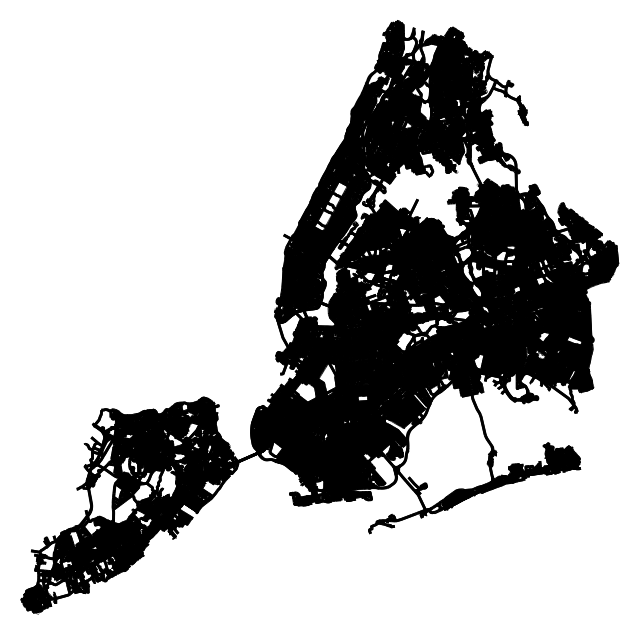

100%|██████████| 36220/36220 [21:00<00:00, 28.72it/s]  


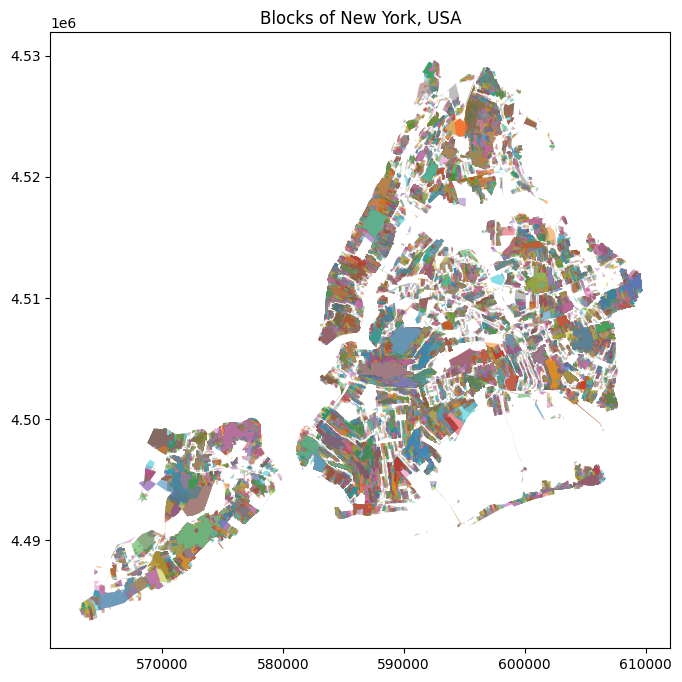

100%|██████████| 30985/30985 [00:26<00:00, 1187.10it/s]


In [210]:
# city_name ="Lviv, Ukraine"
# city_name = "Manhattan, New York, USA"
# city_name = "Brooklyn, New York, USA"
# city_name = "Bronx, New York, USA"
# city_name = "Queens, New York, USA"
# city_name = "Staten Island, New York, USA"

city_name = "New York, USA"

blocks = get_city_blocks(city_name)
block_data = compute_shape_factor(blocks)

In [ ]:
# bin_ranges = [
#     (0, 1e3),
#     (1e3, 1e4),
#     (1e4, 1e5),
#     (1e5, np.inf),
# ]

bin_ranges = [
    (0, 1e3),
    (1e3, 1e4),
    (1e4, 1e5),
    (1e5, 1e6),
    (1e6, 1e7),
    (1e7, np.inf),
]

# bin_ranges = [
#     (1e3/2, 1e4/2),
#     (1e4/2, 1e5/2),
#     (1e5/2, 1e6/2),
#     (1e6/2, 1e7/2),
#     (1e7/2, np.inf),
# ]

# color_names = ["green", "orange", "blue", "red"]
# color_names = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3"]
color_names = ["brown", "#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3", "blue"]

def plot_fingerprint(block_data):

    if len(block_data) == 0:
        print(f"No valid blocks found for {city_name}")
        return

    bin_indices = np.zeros(len(block_data), dtype=int)
    for i, (a_min, a_max) in enumerate(bin_ranges):
        bin_indices[(block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max)]
        bin_indices[(block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max)] = i + 1

    plt.figure(figsize=(8, 6))

    colors = [
        color_names[i-1] if i >= 0 else "transparent"
        for i in bin_indices
    ]

    plt.scatter(
        block_data[:, 1],
        block_data[:, 0],
        c=colors,
        alpha=0.7,
        edgecolors="k",
        s=block_data[:, 0] / 1000,
    )

    plt.xlim(0, 1)
    plt.yscale("log")
    plt.ylim(1e1, 1e8)
    plt.xlabel("Shape Factor (Φ)")
    plt.ylabel("Block Area (log scale)")
    ncname = city_name.split(",")[0].replace(" ", "_")
    plt.title(f"Fingerprint of {ncname}")
    # plt.savefig(f"louf_LVN_{ncname}_ca_t.png")
    plt.show()


def plot_pd(block_data):
    if len(block_data) == 0:
        print(f"No valid blocks found for {city_name}")
        return

    fig, ax = plt.subplots(figsize=(8, 5))

    # area_labels = ["< 10^3", "10^3 - 10^4", "10^4 - 10^5", "> 10^5"]
    colors = color_names

    # bin_edges = np.linspace(0, 1, 51)  # 50 bins between 0 and 1
    bin_edges = np.linspace(0, 1, 30)  # seems to be different in different plots
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total_blocks = len(block_data)

    total_hist = np.zeros_like(bin_centers)

    for i, (a_min, a_max) in enumerate(bin_ranges):
        phi_values = block_data[
            (block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max), 1
        ]
        n = len(phi_values)
        if n == 0:
            continue
        hist, _ = np.histogram(phi_values, bins=bin_edges, density=True)
        weighted_hist = hist * (n / total_blocks)
        total_hist += weighted_hist
        hist, _ = np.histogram(phi_values, bins=bin_edges, density=True)
        weighted_hist = hist * (n / total_blocks)
        ax.plot(bin_centers, weighted_hist, color=colors[i])#, label=area_labels[i])

    ax.plot(
        bin_centers,
        total_hist,
        color="gray",
        linewidth=0.5,
        linestyle="--",
    )
    ax.fill_between(bin_centers, total_hist, color="gray", alpha=0.1)


    ax.set_xlabel(r"$\Phi$", fontsize=14)
    ax.set_ylabel(r"$f(\Phi)$", fontsize=14)
    ax.set_title(f"{city_name}", fontsize=18, weight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


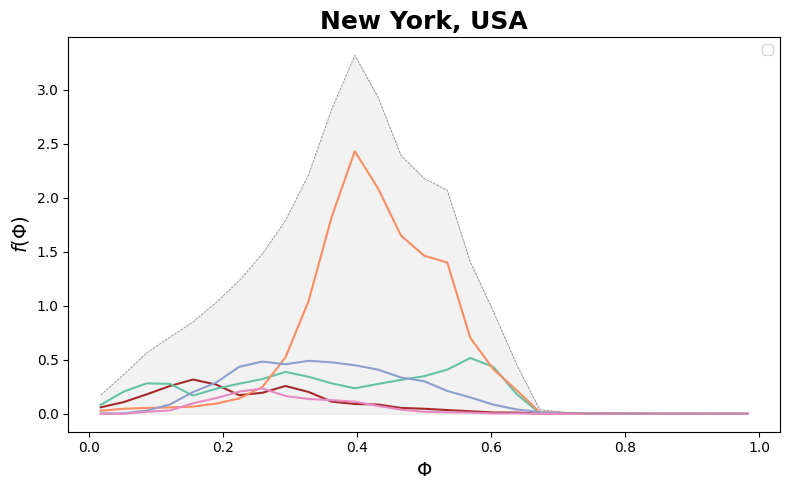

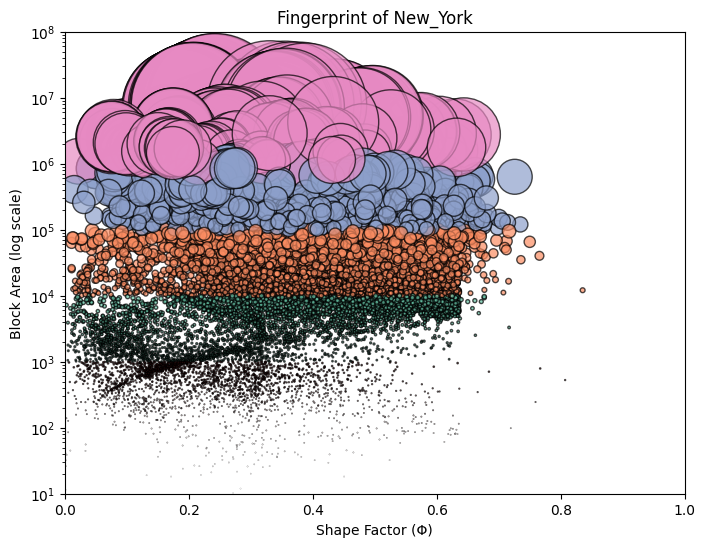

In [212]:
plot_pd(block_data)
plot_fingerprint(block_data)